# Student Information
**Name:** Faisal AL Zahrani  
**Student ID:** 2230000363  
**Lab:** Lab 3 — N-Grams

# N-Grams

It's a probabilistic model that's trained on a corpus of text. Such a model is useful in many NLP applications including speech recognition, machine translation and predictive text input. An N-gram model is built by counting how often word sequences occur in corpus text and then estimating the probabilities.

## Types of N-Grams

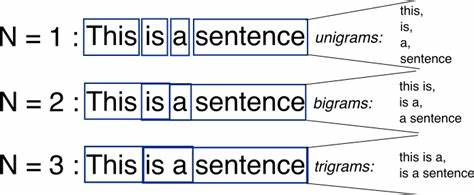

## Use-cases of N-Grams

- Auto completion of sentences
- Auto spell check
- Voice-based personal assistant bots

## Unigram

**Unigram** is an n-gram consisting of a single item of a sequence.

- It is commonly used to calculate the probability of finding a word in an article.

$$
P(A) = \frac{\text{count of } A}{\text{count of all words}}
$$

### Environment Setup
Run the notebook from top to bottom in a Python 3 kernel. This cell installs a required package only if it is missing. The original one-sentence examples use `word_tokenize(..., preserve_line=True)`, which avoids downloading sentence-tokenizer resources. The tweet task uses `TweetTokenizer`.

The completed outputs are saved. A fresh run needs internet access for missing packages and the first dataset download; later runs reuse the downloaded archive.

In [1]:
import importlib.util
import importlib.metadata
import subprocess
import sys

requirements = {"nltk": "nltk==3.9.2", "pandas": "pandas>=2.2,<3",
                "emoji": "emoji==2.16.0", "jinja2": "jinja2>=3.1,<4"}
missing = [requirement for module, requirement in requirements.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])

print("Python:", sys.version.split()[0])
for package in requirements:
    print(f"{package}: {importlib.metadata.version(package)}")

Python: 3.14.0
nltk: 3.9.2
pandas: 2.3.3
emoji: 2.16.0
jinja2: 3.1.6


In [2]:
import nltk
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

unigrams = ngrams(word_tokenize(string, preserve_line=True), 1)

for item in unigrams:
    print(item)

('moses',)
('supposes',)
('his',)
('toeses',)
('are',)
('roses',)
('but',)
('moses',)
('supposes',)
('erroneously',)


### Calculating probabilities in unigram models

In [3]:
# Count tokens, not substrings (e.g., "he" must not match "the").
from collections import Counter

tokens = word_tokenize(string, preserve_line=True)
word_counts = Counter(tokens)
words_frq = sorted(word_counts.items())
words_frq

[('are', 1),
 ('but', 1),
 ('erroneously', 1),
 ('his', 1),
 ('moses', 2),
 ('roses', 1),
 ('supposes', 2),
 ('toeses', 1)]

In [4]:
# Maximum-likelihood unigram probabilities.
probab = [(word, count / len(tokens)) for word, count in words_frq]
print("The probabilities are:")
for word, probability in probab:
    print(f"P({word}) = {probability:.2f}")
assert abs(sum(probability for _, probability in probab) - 1.0) < 1e-12

The probabilities are:
P(are) = 0.10
P(but) = 0.10
P(erroneously) = 0.10
P(his) = 0.10
P(moses) = 0.20
P(roses) = 0.10
P(supposes) = 0.20
P(toeses) = 0.10


## Bigram

A **bigram** is a sequence of two adjacent tokens. It does not have to be a fixed phrase or have a special meaning.

For a bigram language model, the next word is conditioned on the previous word:

$$P(B\mid A)=\frac{C(A,B)}{\sum_w C(A,w)}.$$

With sentence-end padding, each ordinary token has a successor, so the denominator equals $C(A)$.

### Method 1

In [5]:
import nltk
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

bigrams = nltk.bigrams(word_tokenize(string, preserve_line=True))
for i in bigrams:
    print(i)


('moses', 'supposes')
('supposes', 'his')
('his', 'toeses')
('toeses', 'are')
('are', 'roses')
('roses', 'but')
('but', 'moses')
('moses', 'supposes')
('supposes', 'erroneously')


### Method 2

In [6]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

bigrams = ngrams(word_tokenize(string, preserve_line=True),2)

for i in bigrams:
    print(i)

('moses', 'supposes')
('supposes', 'his')
('his', 'toeses')
('toeses', 'are')
('are', 'roses')
('roses', 'but')
('but', 'moses')
('moses', 'supposes')
('supposes', 'erroneously')


# Trigram

A **trigram** is a sequence of three adjacent tokens. A trigram language model predicts a word using the preceding two words as context.

### Method 1

In [7]:
import nltk
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

trigrams = nltk.trigrams(word_tokenize(string, preserve_line=True))

for i in trigrams:
    print(i)


('moses', 'supposes', 'his')
('supposes', 'his', 'toeses')
('his', 'toeses', 'are')
('toeses', 'are', 'roses')
('are', 'roses', 'but')
('roses', 'but', 'moses')
('but', 'moses', 'supposes')
('moses', 'supposes', 'erroneously')


### Method 2

In [8]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

trigrams = ngrams(word_tokenize(string, preserve_line=True),3)

for i in trigrams:
    print(i)


('moses', 'supposes', 'his')
('supposes', 'his', 'toeses')
('his', 'toeses', 'are')
('toeses', 'are', 'roses')
('are', 'roses', 'but')
('roses', 'but', 'moses')
('but', 'moses', 'supposes')
('moses', 'supposes', 'erroneously')


## What is padding in NLP?

**Answer:** In neural NLP models, padding adds special values to make sequences in a batch the same length; masks can prevent those values from affecting the model. In an n-gram language model, boundary padding has a different purpose: it marks the beginning and end of each sentence so the model can learn how sentences start and stop.

For an order-$n$ model, NLTK's `pad_both_ends` adds **$n-1$ start tokens** (`<s>`) and **$n-1$ end tokens** (`</s>`) to each tokenized sentence, before extracting n-grams. Thus bigrams use one token at each end and trigrams use two. This does **not** make all sentences the same length.

In [9]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize


string = "moses supposes his toeses are roses but moses supposes erroneously"

print('------------------- Padding in Bigrams ------------------------------')
list(ngrams(word_tokenize(string, preserve_line=True), pad_left=True, left_pad_symbol="<s>",
                                pad_right=True, right_pad_symbol="</s>", n=2))

------------------- Padding in Bigrams ------------------------------


[('<s>', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'his'),
 ('his', 'toeses'),
 ('toeses', 'are'),
 ('are', 'roses'),
 ('roses', 'but'),
 ('but', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'erroneously'),
 ('erroneously', '</s>')]

In [10]:
print('------------------- Padding in Trigrams ------------------------------')
list(ngrams(word_tokenize(string, preserve_line=True), pad_left=True, left_pad_symbol="<s>",
                                pad_right=True, right_pad_symbol="</s>", n=3))

------------------- Padding in Trigrams ------------------------------


[('<s>', '<s>', 'moses'),
 ('<s>', 'moses', 'supposes'),
 ('moses', 'supposes', 'his'),
 ('supposes', 'his', 'toeses'),
 ('his', 'toeses', 'are'),
 ('toeses', 'are', 'roses'),
 ('are', 'roses', 'but'),
 ('roses', 'but', 'moses'),
 ('but', 'moses', 'supposes'),
 ('moses', 'supposes', 'erroneously'),
 ('supposes', 'erroneously', '</s>'),
 ('erroneously', '</s>', '</s>')]

Alternatively, We can get rid of the parameters by using
> pad_both_ends method in NLTK

**Note the n argument, that tells the function we need padding for bigrams.**

In [11]:
from nltk.lm.preprocessing import pad_both_ends
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

list(ngrams(pad_both_ends(word_tokenize(string, preserve_line=True), n=2), n=2))


[('<s>', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'his'),
 ('his', 'toeses'),
 ('toeses', 'are'),
 ('are', 'roses'),
 ('roses', 'but'),
 ('but', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'erroneously'),
 ('erroneously', '</s>')]

### Training the Maximum Likelihood Model

Maximum likelihood estimation (MLE) uses observed relative frequencies to estimate word probabilities. Preparation consists of tokenizing each sentence, adding boundary tokens, collecting n-grams, and building the training vocabulary.

`padded_everygram_pipeline(n, sentences)` returns two iterators:
1. **Training iterator:** all n-grams of orders 1 through $n$ for each padded sentence.
2. **Vocabulary iterator:** the flattened padded tokens.

The iterators are consumed during training and must be recreated if another model is fitted.

**Original references:** [NLTK language modeling](https://www.nltk.org/api/nltk.lm.html) · [N-gram Language Model with NLTK](https://www.kaggle.com/code/alvations/n-gram-language-model-with-nltk)

In [12]:
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

#Create Bigram Language Model
train, vocab = padded_everygram_pipeline(2, [word_tokenize(string, preserve_line=True)])

In [13]:
from nltk.lm import MLE
lm = MLE(2)
lm.fit(train, vocab) #Train the Maximum Likelihood Model

### Calculating Probabilities
`lm.score(word, context)` estimates the probability of the **word after the context**. Therefore, `lm.score('supposes', ['moses'])` means $P(\mathrm{supposes}\mid\mathrm{moses})$.

In [14]:
print("P(supposes | moses) =", lm.score('supposes', ['moses']))
print("P(moses | supposes) =", lm.score('moses', ['supposes']))
# The second transition is unseen, so unsmoothed MLE assigns probability 0.
assert lm.score('supposes', ['moses']) == 1.0
assert lm.score('moses', ['supposes']) == 0.0

P(supposes | moses) = 1.0
P(moses | supposes) = 0.0


### Evaluating N-Gram Models Using Perplexity

**Perplexity** is the inverse geometric mean of the probabilities assigned to the observed next-token events:

$$\operatorname{PP}=2^{-\frac{1}{N}\sum_{i=1}^{N}\log_2 P(w_i\mid h_i)}.$$

Lower perplexity indicates better prediction **on the same evaluation events and vocabulary**. An unseen event has zero probability under unsmoothed MLE, making the perplexity infinite. The example below checks two observed bigrams; a separate held-out test set is used in the tweet task.

In [15]:
test = [('moses', 'supposes'), ('toeses', 'are')]
print("Example bigram perplexity:", lm.perplexity(test))
assert lm.perplexity(test) == 1.0

Example bigram perplexity: 1.0


## Task: Generating tweets using n_grams

In this Task, we will build a MLE model with n-gram to generate tweets.

The agenda is:
1. load the data:
https://www.kaggle.com/datasets/adizafar/large-random-tweets-from-pakistan

2. pre-processing the data:
*   Remove hashtags
*   Remove RT
*   Remove any website
*   Remove any mentions
*   Remove emojis


3. build MLE model with n-gram (Bi-gram)
4. evaluate the model
5. calculate the probability of the bigram: (pakistan is)
6. calculate the preplexity of the word: (pakistan)

before we start we need to install library to handle the emojis in tweets
> pip install emoji

### Task Checklist
The original notebook contains one practical task with six numbered requirements. The solution below follows their order:

| Part | Requirement |
|---|---|
| 1 | Load the specified Kaggle dataset. |
| 2 | Remove hashtags, RT markers, websites, mentions, and emojis. |
| 3 | Train an MLE bigram model and generate tweets, as requested in the task title. |
| 4 | Evaluate the model using held-out perplexity. |
| 5 | Calculate the bigram probability for **pakistan is**. |
| 6 | Calculate the perplexity of **pakistan** and state its context. |

The earlier unigram, bigram, trigram, padding, MLE, and perplexity examples are also completed and executed. The padding question is answered in its original position.

### Task 1 — Load the Data
Use the exact dataset specified in the lab: [Anonymous – Random Tweets, by Adeel Zafar](https://www.kaggle.com/datasets/adizafar/large-random-tweets-from-pakistan), version 2. Download the archive automatically and read its `full_text` column. No sample or substitute corpus is used.

Some source bytes are invalid UTF-8. Decode them as replacement characters, count affected tweets, and exclude those tweets in Task 2. This preserves valid Urdu and other Unicode text instead of misreading the whole file as Latin-1. The CSV fingerprint verifies the expected source file.

In [16]:
from pathlib import Path
from urllib.request import Request, urlopen
import hashlib
import io
import zipfile
import pandas as pd
from IPython.display import display, Markdown

DATASET_URL = "https://www.kaggle.com/datasets/adizafar/large-random-tweets-from-pakistan"
DOWNLOAD_URL = (
    "https://www.kaggle.com/api/v1/datasets/download/"
    "adizafar/large-random-tweets-from-pakistan?datasetVersionNumber=2"
)
CSV_NAME = "Random Tweets from Pakistan- Cleaned- Anonymous.csv"
EXPECTED_SHA256 = "54c8a9c5259c3a0ce2fe6b370fb82d2ab5c8e1ebc598f3238f8a5814325c62e9"
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
ARCHIVE_PATH = DATA_DIR / "pakistan_tweets_v2.zip"

if not ARCHIVE_PATH.exists():
    request = Request(DOWNLOAD_URL, headers={"User-Agent": "Mozilla/5.0"})
    try:
        with urlopen(request, timeout=120) as response:
            archive_bytes = response.read()
    except Exception as exc:
        raise RuntimeError(
            "Dataset download failed. Download version 2 from " + DATASET_URL
            + " and save its ZIP as data/pakistan_tweets_v2.zip, then rerun."
        ) from exc
    if not zipfile.is_zipfile(io.BytesIO(archive_bytes)):
        raise RuntimeError("Kaggle did not return a ZIP archive. Download version 2 manually.")
    ARCHIVE_PATH.write_bytes(archive_bytes)

with zipfile.ZipFile(ARCHIVE_PATH) as archive:
    csv_bytes = archive.read(CSV_NAME)
csv_sha256 = hashlib.sha256(csv_bytes).hexdigest()
if csv_sha256 != EXPECTED_SHA256:
    raise ValueError("The CSV does not match the version used in this notebook.")

# Read the entire CSV; explicit string types avoid mixed-type warnings.
df = pd.read_csv(io.BytesIO(csv_bytes), encoding="utf-8",
                 encoding_errors="replace", dtype=str)
assert "full_text" in df.columns
print(f"Dataset rows: {len(df):,}; columns: {len(df.columns)}")
print("Tweet column: full_text")
print("CSV SHA-256:", csv_sha256)
print("Missing tweet texts:", int(df["full_text"].isna().sum()))
print("Tweets containing invalid UTF-8:",
      int(df["full_text"].str.contains("\ufffd", regex=False, na=False).sum()))

Dataset rows: 202,202; columns: 7
Tweet column: full_text
CSV SHA-256: 54c8a9c5259c3a0ce2fe6b370fb82d2ab5c8e1ebc598f3238f8a5814325c62e9
Missing tweet texts: 51
Tweets containing invalid UTF-8: 6538


### Task 2 — Clean and Tokenize the Tweets
Remove each entire hashtag (`#tag`, including the word), standalone `RT` markers, URLs and bare website domains, mentions, and emojis. Also normalize case and whitespace, decode HTML entities, and discard punctuation-only and number-only tokens. Keep words from all languages; do not remove stopwords such as **is**, since they are needed for this task.

Drop missing or damaged texts, then empty results and duplicate token sequences. Deduplicating before the split prevents identical cleaned tweets from appearing in both training and testing. Every tweet remains a separate sequence, so no bigram crosses a tweet boundary.

In [17]:
import html
import re
import unicodedata
import emoji
from nltk.tokenize import TweetTokenizer

URL_RE = re.compile(
    r"\b(?:[a-z][a-z0-9+.-]*://|www\.)\S+"
    r"|\b(?:[a-z0-9](?:[a-z0-9-]*[a-z0-9])?\.)+[a-z]{2,63}\b(?:[/:?#]\S*)?",
    flags=re.IGNORECASE,
)
HASHTAG_RE = re.compile(r"#[^\s#@]+")
MENTION_RE = re.compile(r"@[\w]+")
RT_RE = re.compile(r"\brt\b:?", flags=re.IGNORECASE)
tweet_tokenizer = TweetTokenizer(preserve_case=False, reduce_len=False)

def clean_tweet(text):
    """Apply all five required cleaning operations without deleting Unicode words."""
    # Remove emojis before normalization, which can turn symbols into letters.
    text = emoji.replace_emoji(html.unescape(text), replace=" ")
    text = unicodedata.normalize("NFKC", text)
    text = URL_RE.sub(" ", text)
    text = HASHTAG_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = RT_RE.sub(" ", text)
    return " ".join(text.lower().split())

def tokenize_tweet(text):
    # isalpha handles letters from Urdu and other languages, not only English.
    return [token for token in tweet_tokenizer.tokenize(text)
            if any(character.isalpha() for character in token)]

example = "RT @student: Pakistan is beautiful! #Travel https://example.com 😊"
example_cleaned = clean_tweet(example)
print("Before:", example)
print("After: ", example_cleaned)
print("Tokens:", tokenize_tweet(example_cleaned))

# Check the required transformations, including domains and composite emojis.
assert tokenize_tweet(example_cleaned) == ["pakistan", "is", "beautiful"]
assert clean_tweet("RT @a #topic https://x.org www.x.org example.pk 👨‍👩‍👧‍👦 🇵🇰") == ""
assert clean_tweet("hello ™️ ℹ️ world 😊") == "hello world"
assert tokenize_tweet(clean_tweet("پاکستان خوبصورت ہے")) == ["پاکستان", "خوبصورت", "ہے"]
assert tokenize_tweet(clean_tweet("art starts here")) == ["art", "starts", "here"]

Before: RT @student: Pakistan is beautiful! #Travel https://example.com 😊
After:  : pakistan is beautiful!
Tokens: ['pakistan', 'is', 'beautiful']


In [18]:
raw_texts = df["full_text"]
missing_mask = raw_texts.isna()
damaged_mask = raw_texts.str.contains("\ufffd", regex=False, na=False)
valid_texts = raw_texts.loc[~missing_mask & ~damaged_mask]

cleaned_texts = valid_texts.map(clean_tweet)
tokenized_texts = cleaned_texts.map(tokenize_tweet)
empty_mask = tokenized_texts.map(len).eq(0)

# A tuple key also detects duplicates differing only in punctuation.
nonempty_tokens = tokenized_texts.loc[~empty_mask]
duplicate_mask = nonempty_tokens.map(tuple).duplicated(keep="first")
corpus = nonempty_tokens.loc[~duplicate_mask].tolist()

cleaning_report = pd.DataFrame({
    "Stage": ["Original rows", "Missing texts removed", "Damaged texts removed",
              "Empty token sequences removed", "Duplicate sequences removed",
              "Unique usable tweets"],
    "Count": [len(df), int(missing_mask.sum()), int(damaged_mask.sum()),
              int(empty_mask.sum()), int(duplicate_mask.sum()), len(corpus)],
})
display(cleaning_report.style.hide(axis="index").format({"Count": "{:,}"}))
assert len(corpus) == (len(df) - missing_mask.sum() - damaged_mask.sum()
                       - empty_mask.sum() - duplicate_mask.sum())
assert len(corpus) > 1
assert all(corpus)

Stage,Count
Original rows,"202,202"
Missing texts removed,51
Damaged texts removed,"6,538"
Empty token sequences removed,"21,438"
Duplicate sequences removed,"53,903"
Unique usable tweets,"120,272"


### Task 3 — Train the MLE Bigram Model
Shuffle with seed **42**, using 80% of the unique tweets for training and 20% for testing. Build the vocabulary and counts **only from training tweets**. Padding adds one `<s>` and one `</s>` token to each tweet.

$$P(w_i\mid w_{i-1})=\frac{C(w_{i-1},w_i)}{\sum_w C(w_{i-1},w)}.$$

The required model is unsmoothed `MLE(2)`. Its vocabulary includes NLTK's `<UNK>` label, but with the default cutoff of 1 no training word is replaced by it; unknown test words therefore receive zero MLE probability.

In [19]:
import random
from nltk.lm import MLE, Laplace
from nltk.lm.preprocessing import padded_everygram_pipeline, pad_both_ends
from nltk.util import ngrams

RANDOM_SEED = 42
N = 2
shuffled_corpus = corpus.copy()
random.Random(RANDOM_SEED).shuffle(shuffled_corpus)
split_index = int(0.8 * len(shuffled_corpus))
train_tweets = shuffled_corpus[:split_index]
test_tweets = shuffled_corpus[split_index:]

train_ngrams, train_vocabulary = padded_everygram_pipeline(N, train_tweets)
tweet_lm = MLE(N)
tweet_lm.fit(train_ngrams, train_vocabulary)

train_token_count = sum(map(len, train_tweets))
test_token_count = sum(map(len, test_tweets))
print(f"Training tweets: {len(train_tweets):,}; word tokens: {train_token_count:,}")
print(f"Test tweets:     {len(test_tweets):,}; word tokens: {test_token_count:,}")
print(f"Vocabulary size (including boundaries and <UNK>): {len(tweet_lm.vocab):,}")
assert set(map(tuple, train_tweets)).isdisjoint(map(tuple, test_tweets))
assert tweet_lm.order == 2
assert tweet_lm.counts.unigrams.N() == train_token_count + 2 * len(train_tweets)
assert tweet_lm.counts[2].N() == train_token_count + len(train_tweets)

Training tweets: 96,217; word tokens: 1,670,492
Test tweets:     24,055; word tokens: 417,148
Vocabulary size (including boundaries and <UNK>): 118,036


#### Generate Tweets
Sample one next word at a time using the trained bigram model. Start with `<s>` (or a supplied word), stop at `</s>`, and cap output at 30 tokens and 280 characters. Fixed seeds make the examples reproducible. Because the source is multilingual and a bigram sees only one preceding word, generated text may switch languages or lack long-range coherence.

In [20]:
def generate_tweet(model, seed=42, start_word=None, max_words=30, max_chars=280):
    """Generate one tweet; sentence-boundary tokens are never printed."""
    rng = random.Random(seed)
    words = [] if start_word is None else [start_word.lower()]
    context = ["<s>"] if not words else [words[-1]]
    if context[0] not in model.vocab or model.counts[context].N() == 0:
        raise ValueError("The starting context must occur in training.")
    while len(words) < max_words:
        next_word = model.generate(1, text_seed=context, random_seed=rng)
        if next_word == "</s>":
            break
        candidate = " ".join(words + [next_word])
        if len(candidate) > max_chars:
            break
        words.append(next_word)
        context = [next_word]
    return " ".join(words)

generation_settings = [(42, None), (43, None), (44, None),
                       (45, "pakistan"), (46, "pakistan")]
generated_tweets = []
for seed, start_word in generation_settings:
    generated = generate_tweet(tweet_lm, seed=seed, start_word=start_word)
    generated_tweets.append(generated)
    print(f"Seed {seed}, start={start_word or '<s>'}: {generated}")
    assert generated and len(generated) <= 280
    assert "<s>" not in generated and "</s>" not in generated
assert generated_tweets[0] == generate_tweet(tweet_lm, seed=42)

Seed 42, start=<s>: theek


Seed 43, start=<s>: allah next decade ijt none other leader ke
Seed 44, start=<s>: mera ko sno or czech professional chase
Seed 45, start=pakistan: pakistan by ministry because kerala becomes 18th amendment
Seed 46, start=pakistan: pakistan to her mention turkey and mock pm was a body dr moeed yusuf


### Task 4 — Evaluate the Model
Create **only bigrams** from each padded held-out tweet. Include the first-word and end-of-tweet predictions, so the number of evaluated events is the number of test word tokens plus the number of test tweets.

Report held-out MLE perplexity, the fraction of zero-probability events, and the out-of-vocabulary (OOV) word rate. Any zero-probability event makes unsmoothed perplexity $\infty$; those events are **not** removed. An add-one (`Laplace`) model sharing the same training counts and vocabulary provides a separately labeled smoothed comparison.

In [21]:
import math

test_bigrams = [bigram for tweet in test_tweets
                for bigram in ngrams(pad_both_ends(tweet, n=N), N)]
zero_probability_events = sum(tweet_lm.score(word, [previous]) == 0.0
                              for previous, word in test_bigrams)
oov_tokens = sum(word not in tweet_lm.vocab
                 for tweet in test_tweets for word in tweet)
test_perplexity = tweet_lm.perplexity(test_bigrams)

# A supplementary baseline; the required MLE model stays unsmoothed.
laplace_lm = Laplace(N, vocabulary=tweet_lm.vocab, counter=tweet_lm.counts)
laplace_perplexity = laplace_lm.perplexity(test_bigrams)

evaluation = pd.DataFrame({
    "Model": ["MLE bigram (required)", "Laplace bigram (comparison)"],
    "Held-out perplexity": [test_perplexity, laplace_perplexity],
    "Test bigram events": [len(test_bigrams), len(test_bigrams)],
})
display(evaluation.style.hide(axis="index").format({
    "Held-out perplexity": "{:.4f}", "Test bigram events": "{:,}"}))
print(f"Zero-probability MLE events: {zero_probability_events:,} / {len(test_bigrams):,} "
      f"({zero_probability_events / len(test_bigrams):.2%})")
print(f"OOV test word tokens: {oov_tokens:,} / {test_token_count:,} "
      f"({oov_tokens / test_token_count:.2%})")
if zero_probability_events:
    print("MLE perplexity is infinite because at least one test bigram has probability zero.")
else:
    print("All test bigrams have nonzero MLE probability.")
print("Laplace assigns positive probability to unseen events, producing finite perplexity.")
assert len(test_bigrams) == test_token_count + len(test_tweets)
assert math.isinf(test_perplexity) == (zero_probability_events > 0)
assert math.isfinite(laplace_perplexity)

Model,Held-out perplexity,Test bigram events
MLE bigram (required),inf,"441,203"
Laplace bigram (comparison),19697.1588,"441,203"


Zero-probability MLE events: 156,151 / 441,203 (35.39%)
OOV test word tokens: 17,889 / 417,148 (4.29%)
MLE perplexity is infinite because at least one test bigram has probability zero.
Laplace assigns positive probability to unseen events, producing finite perplexity.


### Task 5 — Probability of the Bigram “pakistan is”
In this bigram language model, the requested next-word probability is

$$P(\text{is}\mid\text{pakistan})=\frac{C(\text{pakistan},\text{is})}{C(\text{pakistan})}.$$

Use `score('is', ['pakistan'])`; reversing the arguments answers a different question. The counts below come only from the training split. Since every word has a successor, including `</s>`, the context count equals the token count of **pakistan**.

In [22]:
pakistan_count = tweet_lm.counts[["pakistan"]].N()
pakistan_is_count = tweet_lm.counts[["pakistan"]]["is"]
p_is_given_pakistan = tweet_lm.score("is", ["pakistan"])

assert pakistan_count > 0
assert pakistan_count == tweet_lm.counts["pakistan"]
manual_bigram_probability = pakistan_is_count / pakistan_count
assert math.isclose(p_is_given_pakistan, manual_bigram_probability,
                    rel_tol=1e-12, abs_tol=1e-12)
print(f"C(pakistan, is) = {pakistan_is_count:,}")
print(f"C(pakistan) = {pakistan_count:,}")
print(f"P(is | pakistan) = {pakistan_is_count}/{pakistan_count} "
      f"= {p_is_given_pakistan:.8f} ({p_is_given_pakistan:.4%})")

C(pakistan, is) = 282
C(pakistan) = 6,445
P(is | pakistan) = 282/6445 = 0.04375485 (4.3755%)


### Task 6 — Perplexity of the Word “pakistan”
Perplexity requires a specified prediction event. Since the question gives one word **without a preceding word**, use its unigram probability stored in the MLE model:

$$\operatorname{PP}(\text{pakistan})=\frac{1}{P(\text{pakistan})}.$$

Pass `[('pakistan',)]`, a list containing a one-token tuple, to `perplexity`; a raw string would be interpreted as a sequence of characters. NLTK's unigram denominator here includes `<s>` and `</s>` because the training data was padded.

For clarity, also report (a) predicting **pakistan** immediately after `<s>`, and (b) the complete one-word tweet `<s> pakistan </s>`, whose perplexity covers **two** bigram predictions. These are distinct, explicitly labeled quantities.

In [23]:
p_pakistan = tweet_lm.score("pakistan")
word_perplexity = tweet_lm.perplexity([("pakistan",)])

p_pakistan_at_start = tweet_lm.score("pakistan", ["<s>"])
start_perplexity = tweet_lm.perplexity([("<s>", "pakistan")])
one_word_tweet_bigrams = list(ngrams(pad_both_ends(["pakistan"], n=2), 2))
one_word_tweet_perplexity = tweet_lm.perplexity(one_word_tweet_bigrams)

print(f"C(pakistan) = {tweet_lm.counts['pakistan']:,}")
print(f"Total padded training unigram tokens = {tweet_lm.counts.unigrams.N():,}")
print(f"P(pakistan) = {p_pakistan:.10f}")
print(f"Required context-free word perplexity = {word_perplexity:.6f}")
print(f"P(pakistan | <s>) = {p_pakistan_at_start:.10f}")
display(pd.DataFrame({
    "Interpretation": ["Single word, no context (requested)",
                       "Single word, start-of-tweet context",
                       "Complete one-word tweet, including end"],
    "Events": ["('pakistan',)", "('<s>', 'pakistan')",
               "('<s>', 'pakistan'), ('pakistan', '</s>')"],
    "Perplexity": [word_perplexity, start_perplexity, one_word_tweet_perplexity],
}).style.hide(axis="index").format({"Perplexity": "{:.6f}"}, escape="html"))

assert p_pakistan > 0
assert math.isclose(p_pakistan,
                    tweet_lm.counts["pakistan"] / tweet_lm.counts.unigrams.N())
assert math.isclose(word_perplexity, 1.0 / p_pakistan)
assert math.isclose(start_perplexity, 1.0 / p_pakistan_at_start)

C(pakistan) = 6,445
Total padded training unigram tokens = 1,862,926
P(pakistan) = 0.0034596114
Required context-free word perplexity = 289.049806
P(pakistan | <s>) = 0.0065476995


Interpretation,Events,Perplexity
"Single word, no context (requested)","('pakistan',)",289.049806
"Single word, start-of-tweet context","('<s>', 'pakistan')",152.725397
"Complete one-word tweet, including end","('<s>', 'pakistan'), ('pakistan', '</s>')",35.298280


### Results and Conclusion
All six task requirements have been completed using the supplied dataset, and tweet generation is demonstrated. The summary below is calculated from this run. Infinite held-out MLE perplexity reflects data sparsity; the smoothed comparison shows one way to handle unseen events. Generated tweets demonstrate local word transitions, with limited coherence from the one-word context.

In [24]:
mle_result = "∞ (unseen test bigrams)" if math.isinf(test_perplexity) else f"{test_perplexity:.4f}"
display(Markdown(
    f"- **Usable tweets:** {len(corpus):,}; training: {len(train_tweets):,}; test: {len(test_tweets):,}.\n"
    f"- **Held-out MLE perplexity:** {mle_result}.\n"
    f"- **Held-out Laplace perplexity:** {laplace_perplexity:.4f}.\n"
    f"- **P(is | pakistan):** {p_is_given_pakistan:.8f}.\n"
    f"- **Perplexity of pakistan without context:** {word_perplexity:.6f}.\n"
    f"- **Generated tweets:** {len(generated_tweets)} reproducible examples."
))

- **Usable tweets:** 120,272; training: 96,217; test: 24,055.
- **Held-out MLE perplexity:** ∞ (unseen test bigrams).
- **Held-out Laplace perplexity:** 19697.1588.
- **P(is | pakistan):** 0.04375485.
- **Perplexity of pakistan without context:** 289.049806.
- **Generated tweets:** 5 reproducible examples.

### References
- [Dataset specified in the lab: Anonymous – Random Tweets](https://www.kaggle.com/datasets/adizafar/large-random-tweets-from-pakistan), version 2.
- [NLTK language-model API](https://www.nltk.org/api/nltk.lm.html): padding, MLE, generation, scoring, and perplexity.
- [NLTK tokenization API](https://www.nltk.org/api/nltk.tokenize.html): `word_tokenize` and `TweetTokenizer`.
- [emoji documentation](https://emoji-python.readthedocs.io/en/stable/): removal using `replace_emoji`.
- [Original lab tutorial reference](https://www.kaggle.com/code/alvations/n-gram-language-model-with-nltk).